# Warm-up: K-Means clustering 🎯

Before compressing an image with K-Means, let's build some intuition on the algorithm with a simple 2D example.

## 0) Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 1) Generate a toy dataset

❓ Use `sklearn.datasets.make_blobs` to generate 300 points grouped in 4 clusters in 2D. Plot them.

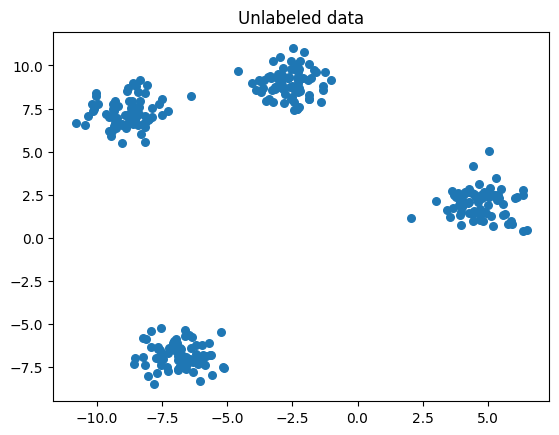

In [2]:
from sklearn.datasets import make_blobs

X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.80, random_state=42)

plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Unlabeled data")
plt.show()

☝️ By eye we can already guess 4 clusters. Let's ask K-Means to find them.

## 2) Fit a K-Means model

❓ Instantiate and fit a `KMeans` model with `n_clusters=4`. Then retrieve:
- the cluster label of each point via `.labels_`
- the coordinates of each centroid via `.cluster_centers_`

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans.fit(X)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

print("Labels shape:", labels.shape)
print("Centers:\n", centers)

Labels shape: (300,)
Centers:
 [[-2.63715917  8.98563949]
 [-6.84180708 -6.84038791]
 [ 4.70253968  2.02807134]
 [-8.83330596  7.21790214]]


❓ Plot the points colored by their assigned cluster and overlay the centroids in red.

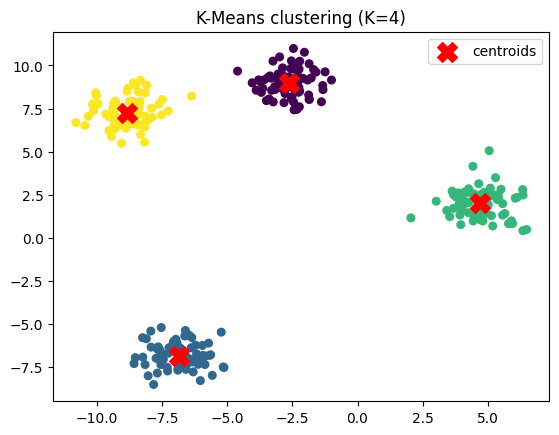

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=labels, s=30, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='centroids')
plt.legend()
plt.title("K-Means clustering (K=4)")
plt.show()

## 3) Choosing K with the elbow method

In real life we rarely know the true number of clusters. A common heuristic is the **elbow method**: plot the inertia (sum of squared distances to closest centroid) as a function of `K`, and pick the `K` where the curve bends.

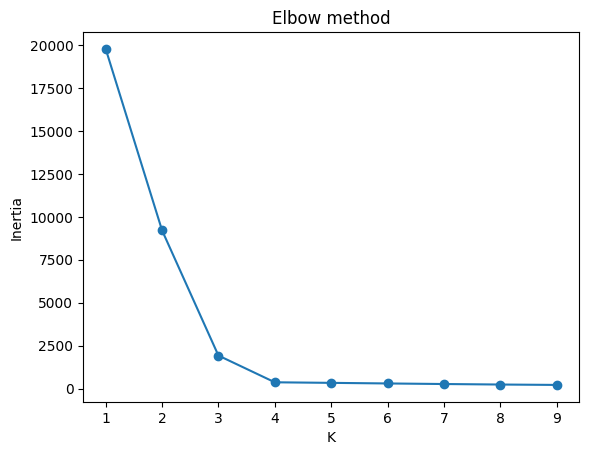

In [5]:
inertias = []
ks = range(1, 10)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)

plt.plot(ks, inertias, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

☝️ The elbow sits around `K=4`, matching the ground truth of the generator.

## 4) Silhouette score

Another more quantitative metric is the **silhouette score** (between -1 and 1). Higher is better.

In [6]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    score = silhouette_score(X, km.labels_)
    print(f"K={k} -> silhouette = {score:.3f}")

K=2 -> silhouette = 0.603
K=3 -> silhouette = 0.778
K=4 -> silhouette = 0.834
K=5 -> silhouette = 0.698
K=6 -> silhouette = 0.588
K=7 -> silhouette = 0.449


🏁 You are now ready to apply K-Means to image compression!